# Newton-Raphson Inspired Root Finding

Root finding by conditioning on f(x)/f'(x) = 0 instead of f(x) = 0.

This approach incorporates derivative information and naturally avoids regions where the derivative is small.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    estimate_sample_size,
    best_gmm,
    best_gmm_bic,
    cluster_stats,
    validate_gmm
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

### 2.3 Newton-Raphson Inspired Root Finding

Instead of conditioning directly on $f(x) = 0$, we can condition on the Newton-Raphson update step:

$$\frac{f(x)}{f'(x)} = 0$$

When this ratio equals zero, we have $f(x) = 0$ (assuming $f'(x) \neq 0$). This is interesting because:
1. It incorporates derivative information into the root-finding process
2. Near roots, the ratio approaches zero more smoothly than $f(x)$ alone
3. It naturally avoids regions where the derivative is small (potential numerical issues in Newton-Raphson)

In [ ]:
# Newton-Raphson inspired: condition on f(x)/f'(x) = 0
# Using the same polynomial: y = x^4 - 4x^2 + x + 3

x = np.linspace(-2.25, 2, 300)
y = x**4 - 4*x**2 + x + 3
y_prime = 4*x**3 - 8*x + 1

# The Newton-Raphson step: f(x)/f'(x)
# Avoid division by zero by filtering out points where |f'(x)| is very small
mask = np.abs(y_prime) > 0.1
x_filtered = x[mask]
y_filtered = y[mask]
y_prime_filtered = y_prime[mask]
nr_step = y_filtered / y_prime_filtered

print(f"Original samples: {len(x)}")
print(f"After filtering (|f'(x)| > 0.1): {len(x_filtered)}")
print(f"Newton-Raphson step range: [{nr_step.min():.3f}, {nr_step.max():.3f}]")

Original samples: 300
After filtering (|f'(x)| > 0.1): 296
Newton-Raphson step range: [-15.052, 23.734]


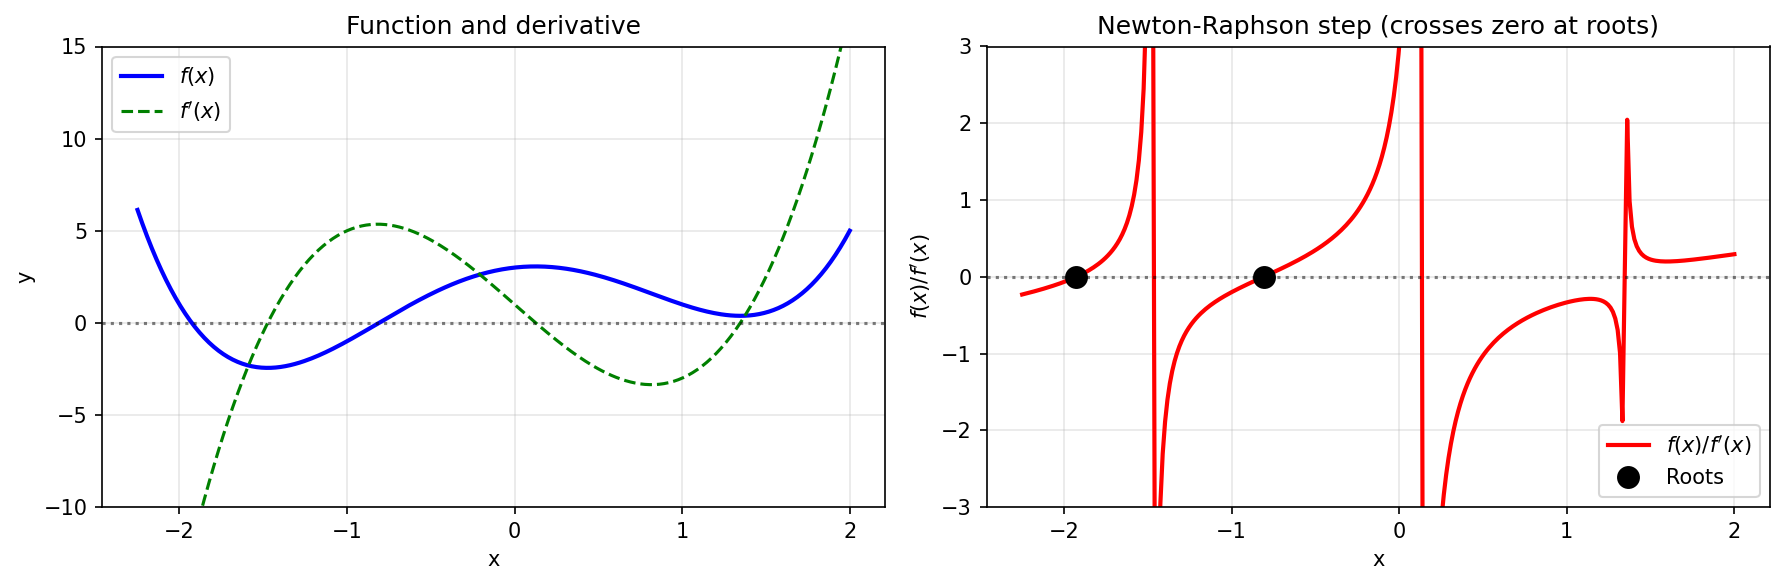

In [ ]:
# Visualize f(x)/f'(x) - it crosses zero at the roots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: original function
axes[0].plot(x, y, 'b-', lw=2, label="$f(x)$")
axes[0].plot(x, y_prime, 'g--', lw=1.5, label="$f'(x)$")
axes[0].axhline(0, color='k', ls=':', alpha=0.5)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].set_title('Function and derivative')
axes[0].set_ylim(-10, 15)
axes[0].grid(True, alpha=0.3)

# Right: Newton-Raphson step
axes[1].plot(x_filtered, nr_step, 'r-', lw=2, label="$f(x)/f'(x)$")
axes[1].axhline(0, color='k', ls=':', alpha=0.5)
axes[1].plot([-1.926, -0.809], [0, 0], 'ko', ms=10, label='Roots')
axes[1].set_xlabel('x')
axes[1].set_ylabel("$f(x)/f'(x)$")
axes[1].legend()
axes[1].set_title('Newton-Raphson step (crosses zero at roots)')
axes[1].set_ylim(-3, 3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Build GMM with x and f(x)/f'(x)
data_nr = np.array([x_filtered, nr_step]).T

gmm_nr, info = best_gmm(data_nr, verbose=True)
print(f"\nBest model: {info['best_k']} components")

k=1: BIC=2381.1 *
k=2: BIC=1937.4 *
k=3: BIC=1870.3 *
k=4: BIC=1634.5 *
k=5: BIC=1575.1 *
k=6: BIC=1222.6 *
k=7: BIC=1033.1 *
k=8: BIC=1122.0
k=9: BIC=1090.5
k=10: BIC=1003.5 *
k=11: BIC=869.4 *
k=12: BIC=711.8 *
k=13: BIC=843.5
k=14: BIC=848.1
k=15: BIC=684.5 *
k=16: BIC=659.7 *
k=17: BIC=598.0 *
k=18: BIC=641.8
k=19: BIC=554.3 *
k=20: BIC=529.8 *
k=21: BIC=564.6
k=22: BIC=491.0 *
k=23: BIC=441.0 *
k=24: BIC=479.4
k=25: BIC=425.8 *
k=26: BIC=438.4
k=27: BIC=440.9
k=28: BIC=382.7 *
k=29: BIC=387.7

Best model: 28 components


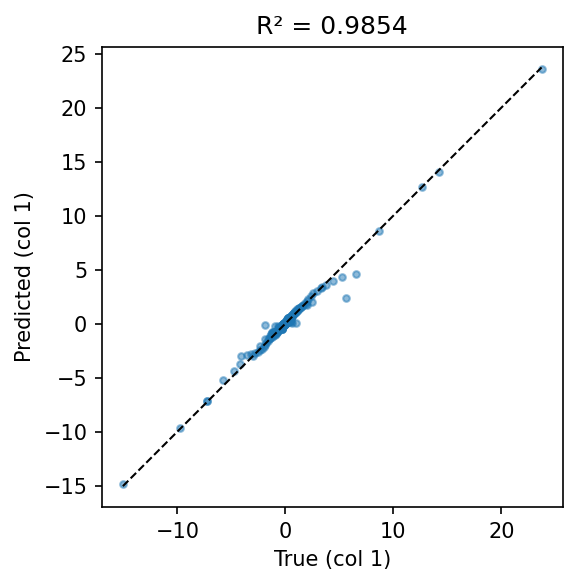


R² = 0.9854


In [ ]:
# Validate the model
metrics = validate_gmm(gmm_nr, data_nr, input_cols=[0], output_cols=[1])
print(f"\nR² = {metrics['col_1']['R2']:.4f}")

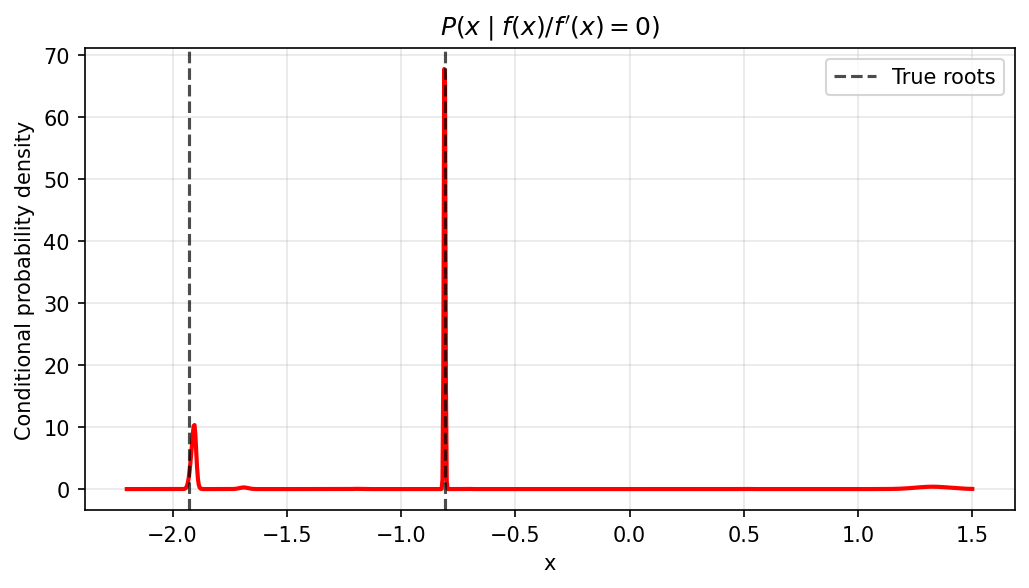

In [ ]:
# Find roots by conditioning on f(x)/f'(x) = 0
c_nr = gmm_nr.condition([1], [[0.0]])

# Visualize conditional probability density
_x = np.linspace(-2.2, 1.5, 1000)[:, None]

plt.figure(figsize=(8, 4))
plt.plot(_x, c_nr.to_probability_density(_x), 'r-', lw=2)
plt.axvline(-1.926, color='k', ls='--', alpha=0.7, label='True roots')
plt.axvline(-0.809, color='k', ls='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Conditional probability density')
plt.title("$P(x \\mid f(x)/f'(x) = 0)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Sample to find roots
print("Roots found by conditioning on f(x)/f'(x) = 0:")
samples_nr = c_nr.sample(1000)
cluster_stats(samples_nr)

print("\nComparison with true roots: -1.926, -0.809")

Roots found by conditioning on f(x)/f'(x) = 0:
 -1:   0.4915 +/- 0.0130 (n=2)
  0:  -0.8097 +/- 0.0054 (n=624)
  1:   1.3164 +/- 0.0666 (n=87)
  2:  -1.8959 +/- 0.0486 (n=287)

Comparison with true roots: -1.926, -0.809


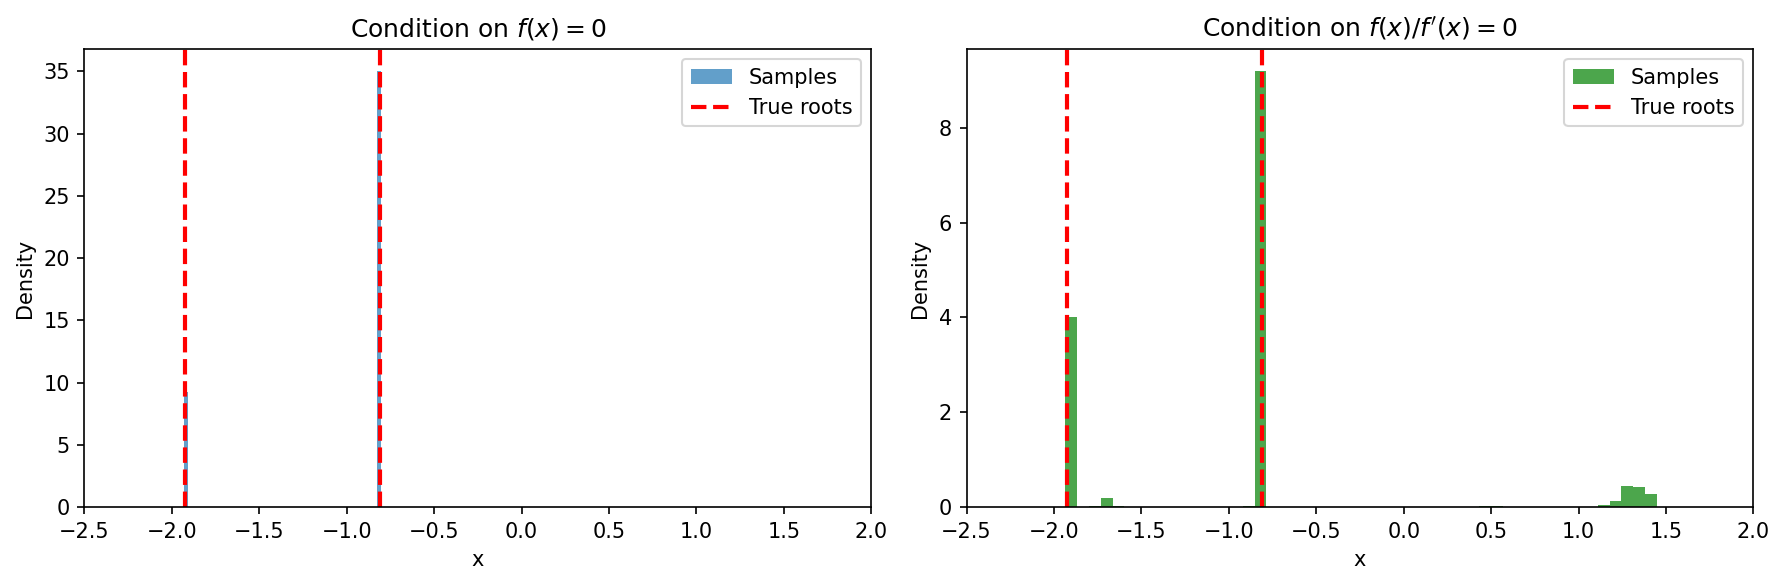

Both methods find the same roots, but the Newton-Raphson approach
naturally excludes regions near stationary points (where f'(x) ≈ 0).


In [ ]:
# Compare: conditioning on f(x)=0 vs f(x)/f'(x)=0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1: Condition on f(x) = 0 (from earlier)
data_fx = np.array([x, y]).T
gmm_fx, _ = best_gmm(data_fx, verbose=False)
c_fx = gmm_fx.condition([1], [[0.0]])
samples_fx = c_fx.sample(1000)

axes[0].hist(samples_fx, bins=50, alpha=0.7, density=True, label='Samples')
axes[0].axvline(-1.926, color='r', ls='--', lw=2, label='True roots')
axes[0].axvline(-0.809, color='r', ls='--', lw=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].set_title('Condition on $f(x) = 0$')
axes[0].legend()
axes[0].set_xlim(-2.5, 2)

# Method 2: Condition on f(x)/f'(x) = 0
axes[1].hist(samples_nr, bins=50, alpha=0.7, density=True, color='green', label='Samples')
axes[1].axvline(-1.926, color='r', ls='--', lw=2, label='True roots')
axes[1].axvline(-0.809, color='r', ls='--', lw=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].set_title("Condition on $f(x)/f'(x) = 0$")
axes[1].legend()
axes[1].set_xlim(-2.5, 2)

plt.tight_layout()
plt.show()

print("Both methods find the same roots, but the Newton-Raphson approach")
print("naturally excludes regions near stationary points (where f'(x) ≈ 0).")